In [ ]:
from google.colab import files
import numpy as np
uploaded=files.upload()


Saving RF25_ind2025_rfp25.nc to RF25_ind2025_rfp25 (1).nc


In [ ]:
!pip install netCDF4
import netCDF4
import numpy as np

file_path = 'RF25_ind2025_rfp25.nc'
# num_days and grid_shape might still be useful as expected dimensions, but we'll infer from NetCDF first.
# num_days = 365
# grid_shape = (135, 129)

try:
    # Open the NetCDF file
    with netCDF4.Dataset(file_path, 'r') as nc_file:
        print("Variables available in the NetCDF file:", list(nc_file.variables.keys()))

        # Attempt to find the largest variable by dimensions, assuming it's the main data
        data_variable_name = None
        max_dims = 0
        for var_name, var in nc_file.variables.items():
            if len(var.shape) > max_dims:
                max_dims = len(var.shape)
                data_variable_name = var_name

        if data_variable_name:
            data = nc_file.variables[data_variable_name][:]
            print(f"Successfully read variable '{data_variable_name}' from the NetCDF file.")
            print("Data shape:", data.shape)
            # Print a few elements for inspection. If data is multidimensional, print a slice or flattened view.
            if data.ndim > 0:
                print("First few elements of data:\n", data.flatten()[:10]) # Display first 10 elements
            else:
                print("Data value:", data)
        else:
            print("Could not infer the main data variable. Please specify the correct variable name from the list above (e.g., 'nc_file.variables['your_variable_name'][:]').")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded correctly to the Colab environment.")
except Exception as e:
    print(f"An error occurred while reading the NetCDF file: {e}")

# Note: The original print("Data shape:", data[1]) was incorrect if data is multidimensional.
# data[1] would try to access the second slice along the first dimension, not the shape.

Variables available in the NetCDF file: ['LONGITUDE', 'LATITUDE', 'TIME', 'RAINFALL']
Successfully read variable 'RAINFALL' from the NetCDF file.
Data shape: (365, 129, 135)
First few elements of data:
 [-- -- -- -- -- -- -- -- -- --]


In [ ]:
print(data)

[[[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 ...

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]

 [[-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  ...
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]
  [-- -- -- ... -- -- --]]]


In [ ]:
import numpy as np

# Check the mask of the data array
print("Shape of the mask:", data.mask.shape)
print("Number of masked values:", np.sum(data.mask))

# Get the unmasked data as a regular NumPy array, filling masked values with NaN
data_filled_nan = data.filled(np.nan)

print("\nFirst few elements after filling masked values with NaN:\n", data_filled_nan.flatten()[:10])
print("Shape of data_filled_nan:", data_filled_nan.shape)

# You can verify that the masked values are now NaN
print("\nChecking if the first masked element is NaN:", np.isnan(data_filled_nan[data.mask][0]) if np.sum(data.mask) > 0 else "No masked values to check")

Shape of the mask: (365, 129, 135)
Number of masked values: 4544615

First few elements after filling masked values with NaN:
 [nan nan nan nan nan nan nan nan nan nan]
Shape of data_filled_nan: (365, 129, 135)

Checking if the first masked element is NaN: True


In [ ]:
import numpy as np

# Calculate the number of non-NaN values in data_filled_nan
non_nan_count = np.sum(~np.isnan(data_filled_nan))
print(f"Number of non-NaN values in data_filled_nan: {non_nan_count}")

# Get all non-NaN values from data_filled_nan
actual_values = data_filled_nan[~np.isnan(data_filled_nan)]

print("\nFirst 10 non-NaN values:")
print(actual_values[:10])

print("\nLast 10 non-NaN values:")
print(actual_values[-10:])

Number of non-NaN values in data_filled_nan: 1811860

First 10 non-NaN values:
[ 0.         0.         1.9280646  5.112836   0.         0.
  5.433482  10.897713   5.8634105 11.767226 ]

Last 10 non-NaN values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Ensure xarray is installed. If not, uncomment and run the following line:
# !pip install xarray

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the NetCDF file using xarray
ds = xr.open_dataset(file_path)

print("Xarray Dataset:")
print(ds)

# Access the 'RAINFALL' data variable
rainfall_data = ds['RAINFALL']
print("\nRainfall Data Variable:")
print(rainfall_data)

# Check the dimensions and coordinates as identified by xarray
print("\nDimensions:", rainfall_data.dims)
print("Coordinates:", rainfall_data.coords)


Xarray Dataset:
<xarray.Dataset> Size: 25MB
Dimensions:    (TIME: 365, LATITUDE: 129, LONGITUDE: 135)
Coordinates:
  * TIME       (TIME) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 38.0 38.25 38.5
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
Data variables:
    RAINFALL   (TIME, LATITUDE, LONGITUDE) float32 25MB ...
Attributes:
    history:      FERRET V6.82    9-Apr-26
    Conventions:  CF-1.0

Rainfall Data Variable:
<xarray.DataArray 'RAINFALL' (TIME: 365, LATITUDE: 129, LONGITUDE: 135)> Size: 25MB
[6356475 values with dtype=float32]
Coordinates:
  * TIME       (TIME) datetime64[ns] 3kB 2025-01-01 2025-01-02 ... 2025-12-31
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 38.0 38.25 38.5
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
Attributes:
    long_name:  Rainfall
    units:      mm
    history:    From ind2025_rfp25.grd

Dimensions: ('T

In [ ]:
!pip install cartopy
import cartopy

Now that we have the data loaded with `xarray`, let's visualize the rainfall for a sample day. We'll pick the first day (index 0) to get an initial look at the spatial distribution.

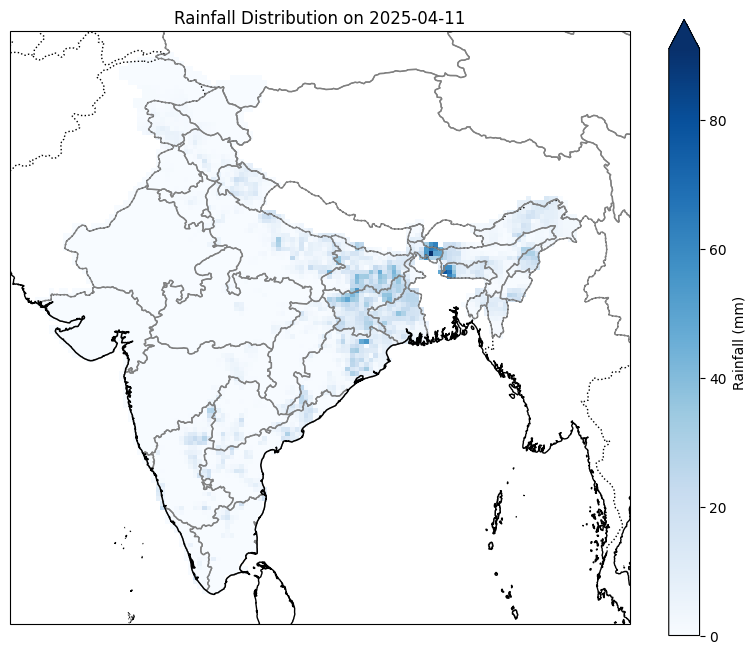

In [ ]:
# Select data for the first day
first_day_rainfall = rainfall_data.isel(TIME=100)

# Plotting using xarray's built-in plot function, which integrates with matplotlib
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the rainfall data
first_day_rainfall.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Rainfall (mm)'},
    cmap='Blues',
    extend='max'
)

# Add geographical features for better context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray') # For India states
ax.coastlines(resolution='10m')

# Set title and labels
ax.set_title(f"Rainfall Distribution on {first_day_rainfall['TIME'].dt.strftime('%Y-%m-%d').item()}")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to focus on India region based on your data's min/max lat/lon
# You might need to adjust these limits based on the actual data's extent
ax.set_extent([float(ds.LONGITUDE.min()), float(ds.LONGITUDE.max()), float(ds.LATITUDE.min()), float(ds.LATITUDE.max())], crs=ccrs.PlateCarree())

plt.show()

### Visualizing the Distribution of NaN Values

Let's plot the `NaN` mask to see where the missing data points are located spatially. We expect them to be outside the region of interest (India) if the data is clipped to a specific geographical area.

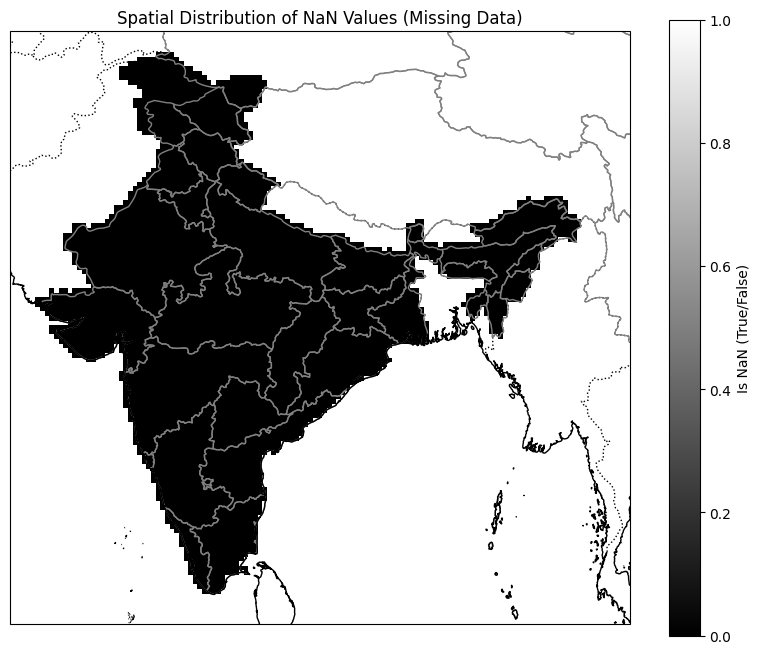

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Select the NaN mask for the first day (or any day, as the mask is static spatially)
nan_mask_first_day = rainfall_data.isel(TIME=0).isnull()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the NaN mask
# Use cmap='binary_r' to show True (NaN) as black/dark and False (data present) as white/light
nan_mask_first_day.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='binary_r', # 'binary_r' for masked (True) to be dark, unmasked (False) to be light
    cbar_kwargs={'label': 'Is NaN (True/False)'}
)

# Add geographical features
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray') # For India states
ax.coastlines(resolution='10m')

# Set title
ax.set_title('Spatial Distribution of NaN Values (Missing Data)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to focus on India region based on your data's min/max lat/lon
ax.set_extent([float(ds.LONGITUDE.min()), float(ds.LONGITUDE.max()), float(ds.LATITUDE.min()), float(ds.LATITUDE.max())], crs=ccrs.PlateCarree())

plt.show()

### Cropping the Data to the Indian Subcontinent

Now that we've confirmed the `NaN` values are mostly outside the region of interest, let's crop the `rainfall_data` to a bounding box that approximates the Indian subcontinent. This will help us focus on the relevant data and reduce computational overhead.

In [ ]:
import xarray as xr

# Define approximate bounding box for the Indian subcontinent
# These values might need fine-tuning based on your specific definition of 'India'
# and the exact coverage of your dataset.
lat_min_india = 5.0 # Southmost tip of India approx
lat_max_india = 38.0 # Northmost extent of India/Himalayas approx
lon_min_india = 65.0 # Westernmost extent approx
lon_max_india = 100.0 # Easternmost extent approx

# Use .sel with slice to crop the data
# We use the min/max values of the original dataset to ensure we don't go out of bounds,
# but still crop to the desired region.
cropped_rainfall_data = rainfall_data.sel(
    LATITUDE=slice(max(float(ds.LATITUDE.min()), lat_min_india), min(float(ds.LATITUDE.max()), lat_max_india)),
    LONGITUDE=slice(max(float(ds.LONGITUDE.min()), lon_min_india), min(float(ds.LONGITUDE.max()), lon_max_india))
)

print("Original rainfall_data shape:", rainfall_data.shape)
print("Cropped rainfall_data shape:", cropped_rainfall_data.shape)

# Display the cropped data for the first time step
print("\nCropped Rainfall Data Variable (first time step):")
print(cropped_rainfall_data.isel(TIME=0))


Original rainfall_data shape: (365, 129, 135)
Cropped rainfall_data shape: (365, 127, 135)

Cropped Rainfall Data Variable (first time step):
<xarray.DataArray 'RAINFALL' (LATITUDE: 127, LONGITUDE: 135)> Size: 69kB
[17145 values with dtype=float32]
Coordinates:
  * LATITUDE   (LATITUDE) float64 1kB 6.5 6.75 7.0 7.25 ... 37.5 37.75 38.0
  * LONGITUDE  (LONGITUDE) float64 1kB 66.5 66.75 67.0 ... 99.5 99.75 100.0
    TIME       datetime64[ns] 8B 2025-01-01
Attributes:
    long_name:  Rainfall
    units:      mm
    history:    From ind2025_rfp25.grd


### Visualizing the Cropped Rainfall Data

Let's visualize the cropped rainfall data for a sample day to confirm that the cropping was successful and now focuses on the Indian subcontinent.

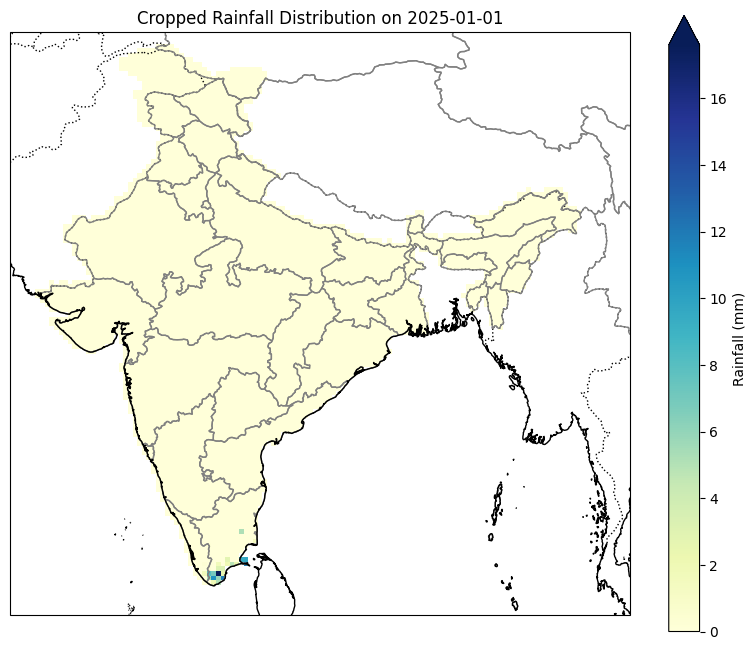

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select data for the first day from the cropped dataset
cropped_first_day_rainfall = cropped_rainfall_data.isel(TIME=0)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plot the cropped rainfall data
cropped_first_day_rainfall.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Rainfall (mm)'},
    cmap='YlGnBu',
    extend='max'
)

# Add geographical features for better context
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray') # For India states
ax.coastlines(resolution='10m')

# Set title and labels
ax.set_title(f"Cropped Rainfall Distribution on {cropped_first_day_rainfall['TIME'].dt.strftime('%Y-%m-%d').item()}")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Set extent to match the cropped data's extent
ax.set_extent([
    float(cropped_rainfall_data.LONGITUDE.min()), float(cropped_rainfall_data.LONGITUDE.max()),
    float(cropped_rainfall_data.LATITUDE.min()), float(cropped_rainfall_data.LATITUDE.max())
], crs=ccrs.PlateCarree())

plt.show()


### Install `cdsapi`

In [ ]:
!pip install cdsapi

###CDS API Credentials part

In [ ]:
import cdsapi
from google.colab import userdata
import os # Import os module to get the home directory

# Retrieve credentials from Colab Secrets
# Ensure these names (CDS_UID, CDS_API_KEY) match exactly what you saved in Colab's Secrets manager
CDS_UID = userdata.get('CDS_UID') # Still retrieve UID for potential future use or context
CDS_API_KEY = userdata.get('CDS_API_KEY')

# The actual file to download will be stored in output_file_lr in the next cell
# For configuring cdsapi, we write .cdsapirc to the user's home directory
user_home_dir = os.path.expanduser('~') # This will typically be '/root' in Colab

# Create the .cdsapirc file for cdsapi to use in the home directory
with open(f'{user_home_dir}/.cdsapirc', 'w') as f:
    f.write(f"""url: https://cds.climate.copernicus.eu/api
key: {CDS_API_KEY}""") # Removed '/v2' and the UID prefix from the key

print("CDS API credentials configured.")

CDS API credentials configured.


### Download Low-Resolution Data from CDS

This example downloads monthly mean total precipitation for January 2025, with a 1-month leadtime, from the ECMWF system 5. Adjust the parameters (`year`, `month`, `variable`, `leadtime_month`, `product_type`, `originating_centre`, `system`, `format`) as needed for your specific low-resolution dataset.

In [ ]:
import cdsapi

# Initialize the CDS client
c = cdsapi.Client()

# Define the output file name
output_file_lr = 'low_res_hindcast_2025_precip.grib' # Renaming file to reflect it's now focused on precip

# Define the request parameters with adjusted product_type for precipitation
c.retrieve(
    'seasonal-monthly-single-levels',
    {
        'originating_centre': 'ecmwf',
        'system': '51', # Using user's specified system
        'variable': [
            'total_precipitation' # Focusing solely on total precipitation
        ],
        'product_type': 'hindcast_monthly_mean', # Changed from 'hindcast_climate_mean'
        'year': [
            '2025' # Setting year to 2025 to match the high-resolution dataset
        ],
        'month': [
            '01', '02', '03',
            '04', '05', '06',
            '07', '08', '09',
            '10', '11', '12'
        ],
        'leadtime_month': [
            '1',
            '2',
            '3',
            '4',
            '5',
            '6'
        ],
        'data_format': 'grib'
    },
    output_file_lr)

print(f"downloaded low-resolution precipitation data to {output_file_lr}")

2026-05-21 07:17:33,253 INFO Request ID is 216a5ee1-9aa5-41c0-938a-ef7f29ee749d
INFO:ecmwf.datastores.legacy_client:Request ID is 216a5ee1-9aa5-41c0-938a-ef7f29ee749d
2026-05-21 07:17:33,529 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-05-21 07:17:42,560 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-05-21 07:17:47,865 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


6dd4df869c3dc3709a4b2e13483c4acb.grib:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

downloaded low-resolution precipitation data to low_res_hindcast_2025_precip.grib


In [ ]:
# Install cfgrib for xarray to open GRIB files
!pip install cfgrib

Low-resolution Xarray Dataset:
<xarray.Dataset> Size: 196MB
Dimensions:     (time: 12, step: 21, latitude: 180, longitude: 360)
Coordinates:
  * time        (time) datetime64[ns] 96B 2025-01-01 2025-02-01 ... 2025-12-01
  * step        (step) timedelta64[ns] 168B 28 days 30 days ... 184 days
  * latitude    (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude   (longitude) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
    number      int64 8B ...
    surface     float64 8B ...
    valid_time  (time, step) datetime64[ns] 2kB ...
Data variables:
    mx2t24      (time, step, latitude, longitude) float32 65MB ...
    mn2t24      (time, step, latitude, longitude) float32 65MB ...
    tprate      (time, step, latitude, longitude) float32 65MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF

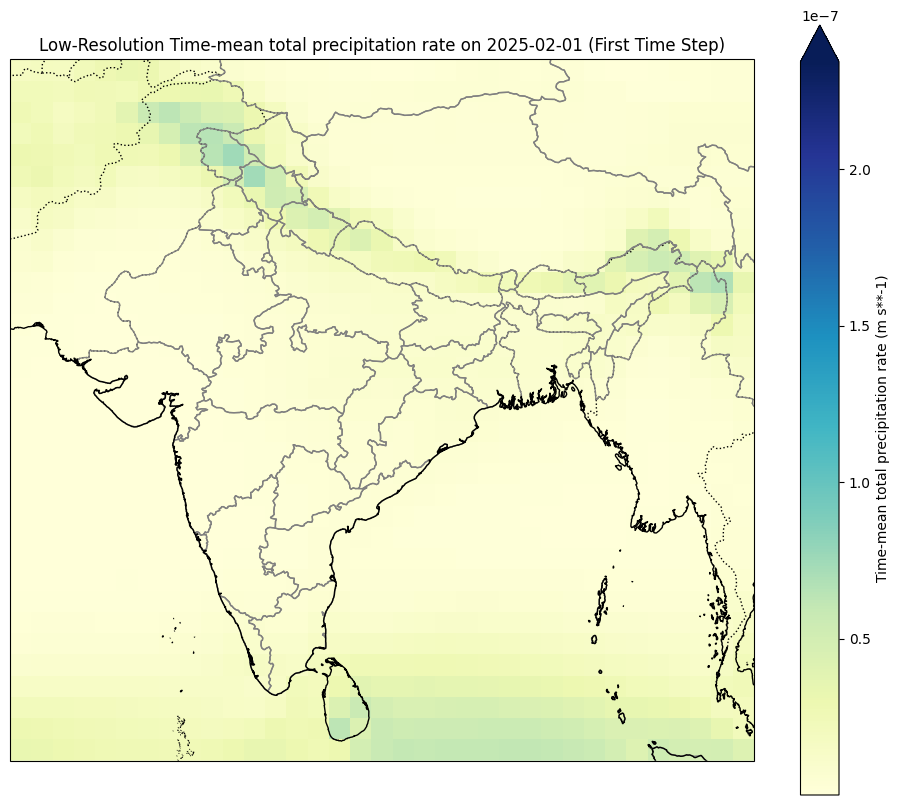

In [ ]:
import cfgrib # Explicitly import cfgrib first, sometimes order matters
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd # For datetime formatting

# Open the GRIB file using xarray with the cfgrib engine
try:
    ds_lr = xr.open_dataset(output_file_lr, engine="cfgrib")
    print("Low-resolution Xarray Dataset:")
    print(ds_lr)

    # Dynamically find the precipitation variable name.
    # Common short name for total precipitation in ECMWF GRIB data is 'tp'.
    # Fallback to 'total_precipitation' if 'tp' is not found.
    precipitation_var_key = None
    if 'tp' in ds_lr.data_vars:
        precipitation_var_key = 'tp'
    elif 'total_precipitation' in ds_lr.data_vars:
        precipitation_var_key = 'total_precipitation'
    elif 'tprate' in ds_lr.data_vars: # Added 'tprate' based on available variables
        precipitation_var_key = 'tprate'

    if precipitation_var_key:
        print(f"\nFound precipitation variable: '{precipitation_var_key}'")
        # Select the first time step for visualization
        # Also select the first 'step' dimension if it exists and has multiple values
        if 'step' in ds_lr[precipitation_var_key].dims:
            low_res_precipitation = ds_lr[precipitation_var_key].isel(time=1, step=0)
        else:
            low_res_precipitation = ds_lr[precipitation_var_key].isel(time=0)

        fig = plt.figure(figsize=(12, 10)) # Adjust figure size for better display
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

        # Get units and long name for the color bar and title
        units = low_res_precipitation.attrs.get('units', 'Unknown Units')
        var_long_name = low_res_precipitation.attrs.get('long_name', precipitation_var_key)

        low_res_precipitation.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={'label': f'{var_long_name} ({units})'},
            cmap='YlGnBu', # A good colormap for precipitation
            extend='max'
        )

        # Add geographical features
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
        ax.add_feature(cfeature.STATES, edgecolor='gray')
        ax.coastlines(resolution='10m')

        # Dynamically get date for title
        date_str = pd.to_datetime(low_res_precipitation['time'].item()).strftime('%Y-%m-%d') if 'time' in low_res_precipitation.coords else 'N/A'

        # Ensure the extent covers the Indian subcontinent as defined for the high-res data
        ax.set_extent([
            lon_min_india, lon_max_india,
            lat_min_india, lat_max_india
        ], crs=ccrs.PlateCarree())

        ax.set_title(f"Low-Resolution {var_long_name} on {date_str} (First Time Step)")
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')

        plt.show()
    else:
        print("Could not find a recognized precipitation variable (e.g., 'tp', 'total_precipitation', or 'tprate') in the low-resolution dataset.")
        print("Available variables: ", list(ds_lr.data_vars.keys()))

except Exception as e:
    print(f"Error opening GRIB file with xarray: {e}")
    print("Please ensure 'cfgrib' is installed and that the GRIB file is valid. A Colab runtime restart might be necessary after installing cfgrib.")

### Preprocessing Low-Resolution Data

To prepare the low-resolution data for comparison with the high-resolution rainfall data, we need to perform a few steps:

1.  **Select the relevant variable**: We will focus on `tprate` (total precipitation rate).
2.  **Select a specific lead time (step)**: Since the high-resolution data is daily, and the low-resolution has multiple lead times, for initial comparison, we will select the first lead time (`step=0`), which corresponds to a 28-day period. Further temporal alignment or aggregation will be considered later.
3.  **Crop geographically**: We will crop the low-resolution data to the same bounding box as the high-resolution data (Indian subcontinent).
4.  **Convert units**: The `tprate` variable is in `m s**-1`. We need to convert this to total precipitation in `mm` over the duration of the selected `step` (e.g., 28 days).


In [ ]:
import numpy as np

# --- Now processing 'tprate' again with new download ---

# Select the 'tprate' variable (total precipitation rate)
low_res_tprate = ds_lr['tprate']

# Select the first step (lead time) for all time initializations
# The step=0 corresponds to the first forecast period, which is '28 days'
# as observed from ds_lr['step'].values
low_res_tprate_first_step = low_res_tprate.isel(step=0)

# Crop the data to the Indian subcontinent using the same bounding box as high-res data
# IMPORTANT: For descending latitudes in ds_lr, the slice must be from max to min latitude
cropped_low_res_tprate = low_res_tprate_first_step.sel(
    latitude=slice(lat_max_india, lat_min_india), # Corrected: slice from max to min for descending coords
    longitude=slice(lon_min_india, lon_max_india)
)

# Get the duration of this step in seconds
# The step is a timedelta, so we convert it to seconds
step_duration_seconds = low_res_tprate['step'].isel(step=0).values.astype('timedelta64[s]').item().total_seconds()

# Convert precipitation rate (m/s) to total precipitation (mm) for the step duration
# 1 m = 1000 mm
# total_precipitation (mm) = tprate (m/s) * step_duration (s) * 1000 (mm/m)
cropped_low_res_precipitation_mm = cropped_low_res_tprate * step_duration_seconds * 1000

# Update attributes for clarity
cropped_low_res_precipitation_mm.attrs['units'] = 'mm'
cropped_low_res_precipitation_mm.attrs['long_name'] = 'Total Precipitation for Forecast Period'

print("Original low-resolution tprate shape:", low_res_tprate.shape)
print("Cropped low-resolution precipitation (mm) shape:", cropped_low_res_precipitation_mm.shape)

print("\nPreprocessed Low-Resolution Precipitation (first time initialization):")
print(cropped_low_res_precipitation_mm.isel(time=0))


Original selected_var shape: (12, 21, 180, 360)
Cropped selected_var (processed) shape: (12, 33, 35)

Preprocessed Low-Resolution Temperature (first time initialization):
<xarray.DataArray 'mx2t24' (latitude: 33, longitude: 35)> Size: 5kB
[1155 values with dtype=float32]
Coordinates:
  * latitude    (latitude) float64 264B 37.5 36.5 35.5 34.5 ... 8.5 7.5 6.5 5.5
  * longitude   (longitude) float64 280B 65.5 66.5 67.5 68.5 ... 97.5 98.5 99.5
    number      int64 8B ...
    time        datetime64[ns] 8B 2025-01-01
    step        timedelta64[ns] 8B 28 days
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             51
    GRIB_dataType:                            hcmean
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                

### Visualize Preprocessed Low-Resolution Data

Let's visualize the preprocessed low-resolution total precipitation for the first time initialization (January 2025 initialisation, for the first 28-day lead period).

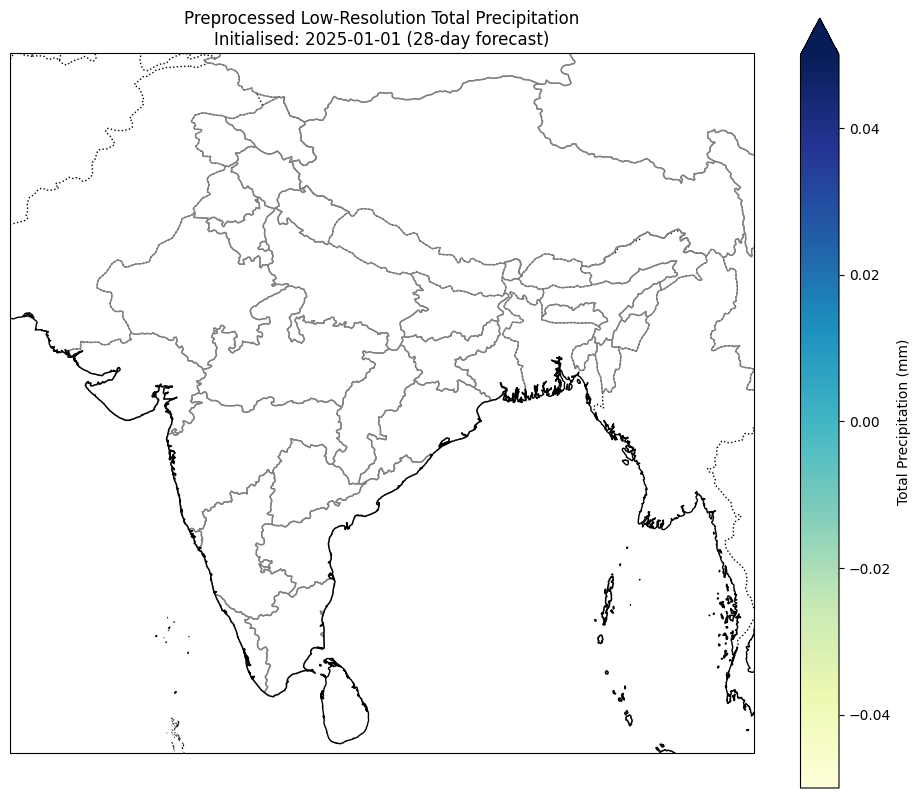

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

# Select the first time initialization for visualization
first_init_low_res_precip = cropped_low_res_precipitation_mm.isel(time=0)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

first_init_low_res_precip.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label': 'Total Precipitation (mm)'},
    cmap='YlGnBu', # A good colormap for precipitation
    extend='max'
)

# Add geographical features
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.coastlines(resolution='10m')

# Dynamically get date for title
date_str = pd.to_datetime(first_init_low_res_precip['time'].item()).strftime('%Y-%m-%d')

# Set extent to match the cropped data's extent
ax.set_extent([
    float(cropped_low_res_precipitation_mm.longitude.min()), float(cropped_low_res_precipitation_mm.longitude.max()),
    float(cropped_low_res_precipitation_mm.latitude.min()), float(cropped_low_res_precipitation_mm.latitude.max())
], crs=ccrs.PlateCarree())

ax.set_title(f"Preprocessed Low-Resolution Total Precipitation\nInitialised: {date_str} (28-day forecast)")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()


### Checking for Null Values in Processed Datasets

In [ ]:


print("\nNull values in cropped_low_res_precipitation_mm:")
print(cropped_low_res_precipitation_mm.isnull().sum())

Null values in cropped_rainfall_data:
<xarray.DataArray 'RAINFALL' ()> Size: 8B
array(4446065)
Attributes:
    long_name:  Rainfall
    units:      mm
    history:    From ind2025_rfp25.grd

Null values in cropped_low_res_precipitation_mm:
<xarray.DataArray 'tprate' ()> Size: 8B
array(12705)
Coordinates:
    number   int64 8B ...
    step     timedelta64[ns] 8B 28 days
    surface  float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             172228
    GRIB_dataType:                            hcmean
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           tprate
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                Total Precipita

### Null Values in Low-Resolution Precipitation Data

In [ ]:
print("Null values in cropped_low_res_precipitation_mm:")
print(cropped_low_res_precipitation_mm.isnull().sum())

Null values in cropped_low_res_precipitation_mm:
<xarray.DataArray 'tprate' ()> Size: 8B
array(12705)
Coordinates:
    number   int64 8B ...
    step     timedelta64[ns] 8B 28 days
    surface  float64 8B ...
Attributes: (12/31)
    GRIB_paramId:                             172228
    GRIB_dataType:                            hcmean
    GRIB_numberOfPoints:                      64800
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           tprate
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                Total Precipitation for Forecas...
    units:                                    mm
    standard_name:                            unknown


### Comparing High-Resolution and Low-Resolution Data Characteristics

In [ ]:
print("--- High-Resolution Rainfall Data (cropped_rainfall_data) ---")
print(f"Shape: {cropped_rainfall_data.shape}")
print(f"Dimensions: {cropped_rainfall_data.dims}")
print(f"Resolution (approx. lat, lon): {abs(cropped_rainfall_data.LATITUDE.diff('LATITUDE').mean().item()):.2f} deg, {abs(cropped_rainfall_data.LONGITUDE.diff('LONGITUDE').mean().item()):.2f} deg")
print(f"Temporal resolution: {cropped_rainfall_data.TIME.diff('TIME').mean().astype('timedelta64[D]').item()} day(s)")
print(f"Time range: {cropped_rainfall_data.TIME.min().item()} to {cropped_rainfall_data.TIME.max().item()}")
print(f"Latitude range: {cropped_rainfall_data.LATITUDE.min().item():.2f} to {cropped_rainfall_data.LATITUDE.max().item():.2f}")
print(f"Longitude range: {cropped_rainfall_data.LONGITUDE.min().item():.2f} to {cropped_rainfall_data.LONGITUDE.max().item():.2f}")

print("\n--- Low-Resolution Precipitation Data (cropped_low_res_precipitation_mm) ---")
print(f"Shape: {cropped_low_res_precipitation_mm.shape}")
print(f"Dimensions: {cropped_low_res_precipitation_mm.dims}")
print(f"Resolution (approx. lat, lon): {abs(cropped_low_res_precipitation_mm.latitude.diff('latitude').mean().item()):.2f} deg, {abs(cropped_low_res_precipitation_mm.longitude.diff('longitude').mean().item()):.2f} deg")
print(f"Temporal resolution: {cropped_low_res_precipitation_mm.time.diff('time').mean().astype('timedelta64[D]').item()} day(s) (initialization period)")
print(f"Time range: {cropped_low_res_precipitation_mm.time.min().item()} to {cropped_low_res_precipitation_mm.time.max().item()}")
print(f"Forecast step duration: {step_duration_seconds / (24 * 3600):.0f} days")
print(f"Latitude range: {cropped_low_res_precipitation_mm.latitude.min().item():.2f} to {cropped_low_res_precipitation_mm.latitude.max().item():.2f}")
print(f"Longitude range: {cropped_low_res_precipitation_mm.longitude.min().item():.2f} to {cropped_low_res_precipitation_mm.longitude.max().item():.2f}")

--- High-Resolution Rainfall Data (cropped_rainfall_data) ---
Shape: (365, 127, 135)
Dimensions: ('TIME', 'LATITUDE', 'LONGITUDE')
Resolution (approx. lat, lon): 0.25 deg, 0.25 deg
Temporal resolution: 1 day, 0:00:00 day(s)
Time range: 1735689600000000000 to 1767139200000000000
Latitude range: 6.50 to 38.00
Longitude range: 66.50 to 100.00

--- Low-Resolution Precipitation Data (cropped_low_res_precipitation_mm) ---
Shape: (12, 33, 35)
Dimensions: ('time', 'latitude', 'longitude')
Resolution (approx. lat, lon): 1.00 deg, 1.00 deg
Temporal resolution: 30 days, 0:00:00 day(s) (initialization period)
Time range: 1735689600000000000 to 1764547200000000000
Forecast step duration: 28 days
Latitude range: 5.50 to 37.50
Longitude range: 65.50 to 99.50
